In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [7]:
metrics_df = pd.read_json("metrics.json")
metrics_df["engine"] = metrics_df['model'].apply(lambda x: "vLLM" if "nvidia/Llama-3.1-8B-Instruct-NVFP4" in x else "Ollama")
metrics_df["concurrent_requests"].drop(metrics_df[metrics_df["concurrent_requests"] == 16.01].index, inplace=True)
metrics_df["concurrent_requests"] = metrics_df["concurrent_requests"].astype(int)
metrics_df["requests_per_sec"] = metrics_df["requests_per_sec"].astype(int)
metrics_df["model"] = metrics_df["model"].replace("meta-llama/Llama-3.1-8B", "Meta LLaMA 3.1 8B").replace("nvidia/Llama-3.1-8B-Instruct-NVFP4", "NVIDIA LLaMA 3.1 8B")
metrics_df.head()

,timestamp,model,url,requests_per_sec,tokens_per_sec,avg_latency_s,p50_latency_s,p95_latency_s,wall_time_s,requests,concurrent_requests,engine
0,2026-05-08 07:48:16.673060894,NVIDIA LLaMA 3.1 8B,http://localhost:8000/v1/chat/completions,6,241.248306,0.157456,0.156779,0.161214,157.514059,1000,1,vLLM
1,2026-05-08 07:53:12.984575272,NVIDIA LLaMA 3.1 8B,http://localhost:8000/v1/chat/completions,11,443.831292,0.171151,0.170862,0.174252,85.618118,1000,2,vLLM
2,2026-05-08 07:57:42.072469473,NVIDIA LLaMA 3.1 8B,http://localhost:8000/v1/chat/completions,23,880.324519,0.172459,0.172355,0.173676,43.165900,1000,4,vLLM
3,2026-05-08 08:00:23.145840645,NVIDIA LLaMA 3.1 8B,http://localhost:8000/v1/chat/completions,42,1617.517380,0.187263,0.176454,0.180189,23.492792,1000,8,vLLM
4,2026-05-08 08:04:53.342764616,NVIDIA LLaMA 3.1 8B,http://localhost:8000/v1/chat/completions,65,2503.015673,0.240690,0.195242,0.211295,15.181687,1000,16,vLLM


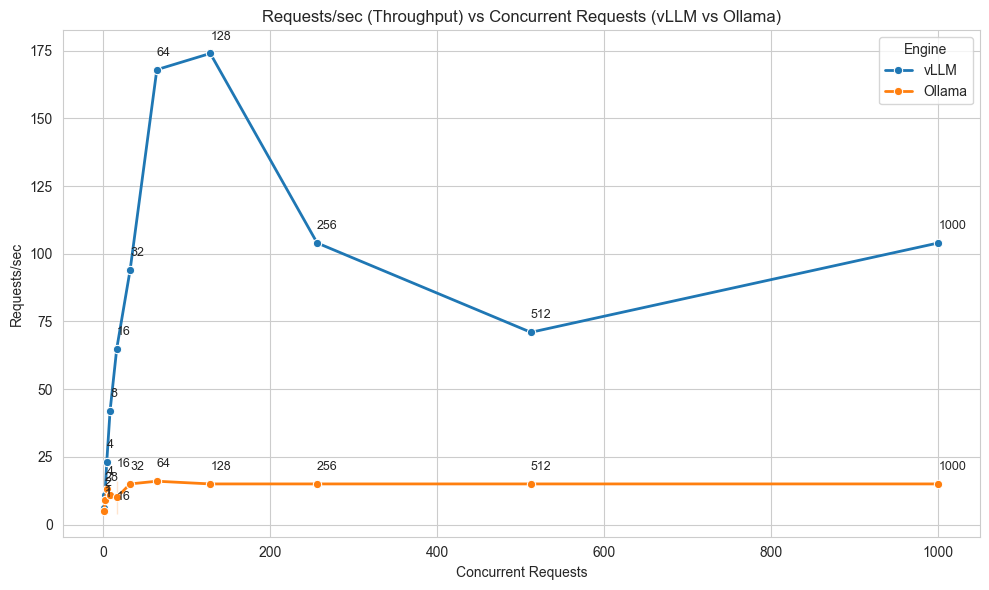

In [50]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=metrics_df.sort_values("concurrent_requests"),
    x="concurrent_requests",
    y="requests_per_sec",
    hue="engine",
    marker="o",
    linewidth=2,
    ax=ax
)
plt.title("Requests/sec (Throughput) vs Concurrent Requests (vLLM vs Ollama)")
plt.xlabel("Concurrent Requests")
plt.ylabel("Requests/sec")

for conc_req, rps in zip(metrics_df["concurrent_requests"], metrics_df["requests_per_sec"]):
    ax.annotate(f"{conc_req}", (conc_req, rps), textcoords="offset points", xytext=(0,10), ha='left', fontsize=9)

plt.legend(title="Engine")
plt.tight_layout()
plt.show()  

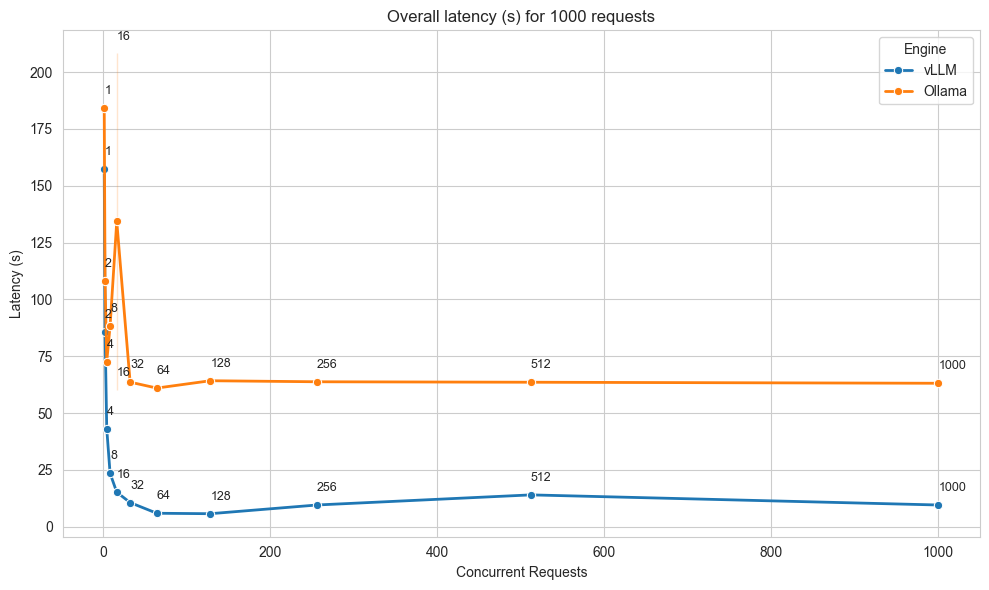

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=metrics_df.sort_values("concurrent_requests"),
    x="concurrent_requests",
    y="wall_time_s",
    hue="engine",
    marker="o",
    linewidth=2,
    ax=ax
)
plt.title("Overall latency (s) for 1000 requests")
plt.xlabel("Concurrent Requests")
plt.ylabel("Latency (s)")

for conc_req, latency in zip(metrics_df["concurrent_requests"], metrics_df["wall_time_s"]):
    ax.annotate(f"{conc_req}", (conc_req, latency), textcoords="offset points", xytext=(0,10), ha='left', fontsize=9)

plt.legend(title="Engine")
plt.tight_layout()
plt.show()  

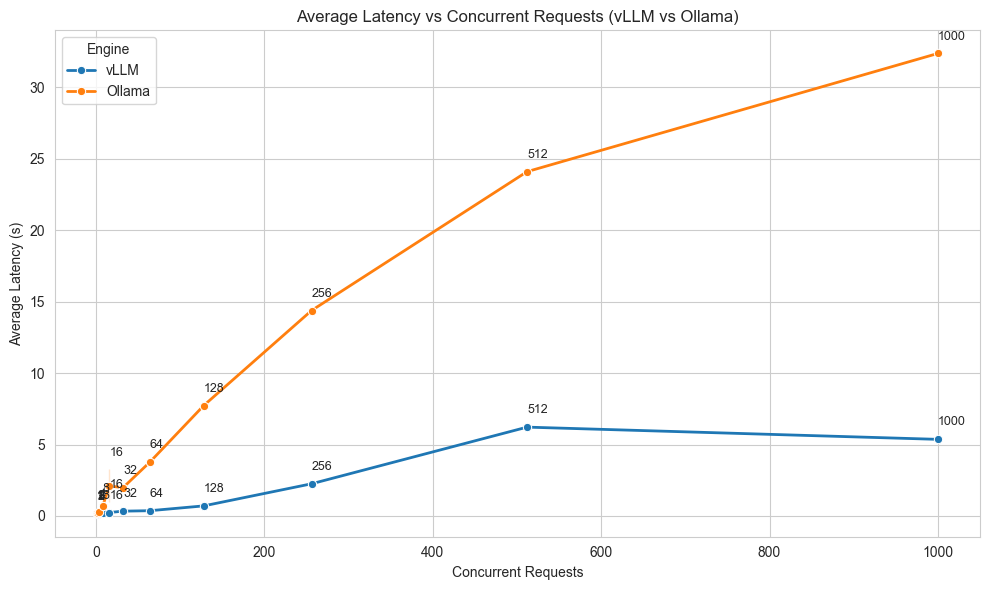

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=metrics_df.sort_values("concurrent_requests"),
    x="concurrent_requests",
    y="avg_latency_s",
    hue="engine",
    marker="o",
    linewidth=2,
    ax=ax
)
plt.title("Average Latency vs Concurrent Requests (vLLM vs Ollama)")
plt.xlabel("Concurrent Requests")
plt.ylabel("Average Latency (s)")

for conc_req, latency in zip(metrics_df["concurrent_requests"], metrics_df["avg_latency_s"]):
    ax.annotate(f"{conc_req}", (conc_req, latency), textcoords="offset points", xytext=(0,10), ha='left', fontsize=9)

plt.legend(title="Engine")
plt.tight_layout()
plt.show()

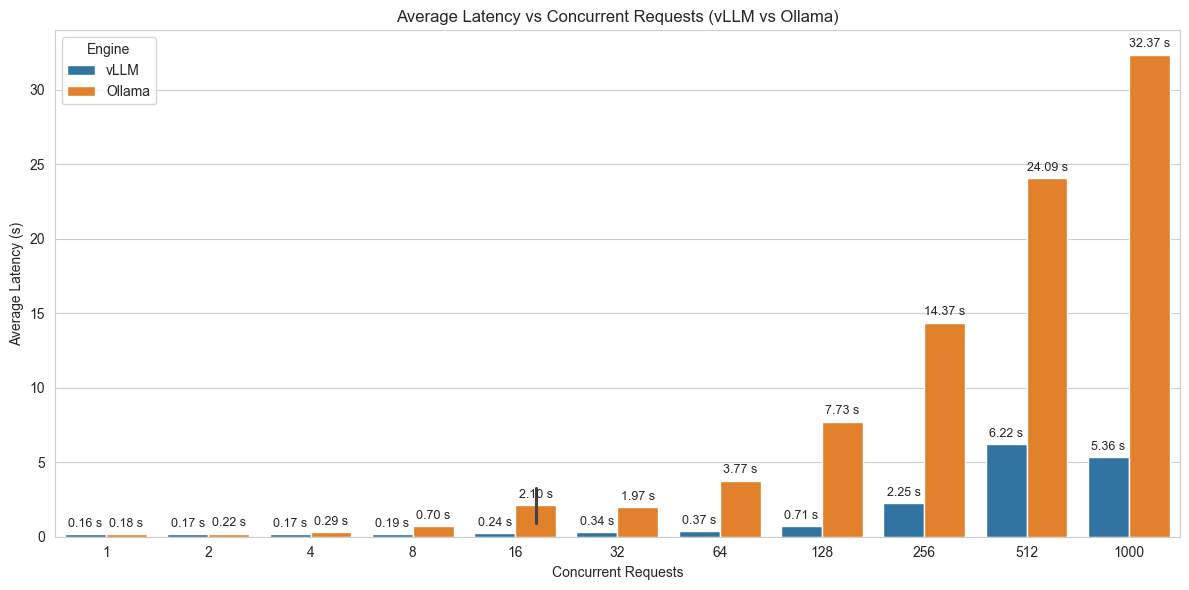

In [52]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=metrics_df.sort_values("concurrent_requests"),
    x="concurrent_requests",
    y="avg_latency_s",
    hue="engine",
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f s",
        padding=3,
        fontsize=9
    )

plt.title("Average Latency vs Concurrent Requests (vLLM vs Ollama)")
plt.xlabel("Concurrent Requests")
plt.ylabel("Average Latency (s)")

plt.legend(title="Engine")
plt.tight_layout()
plt.show()

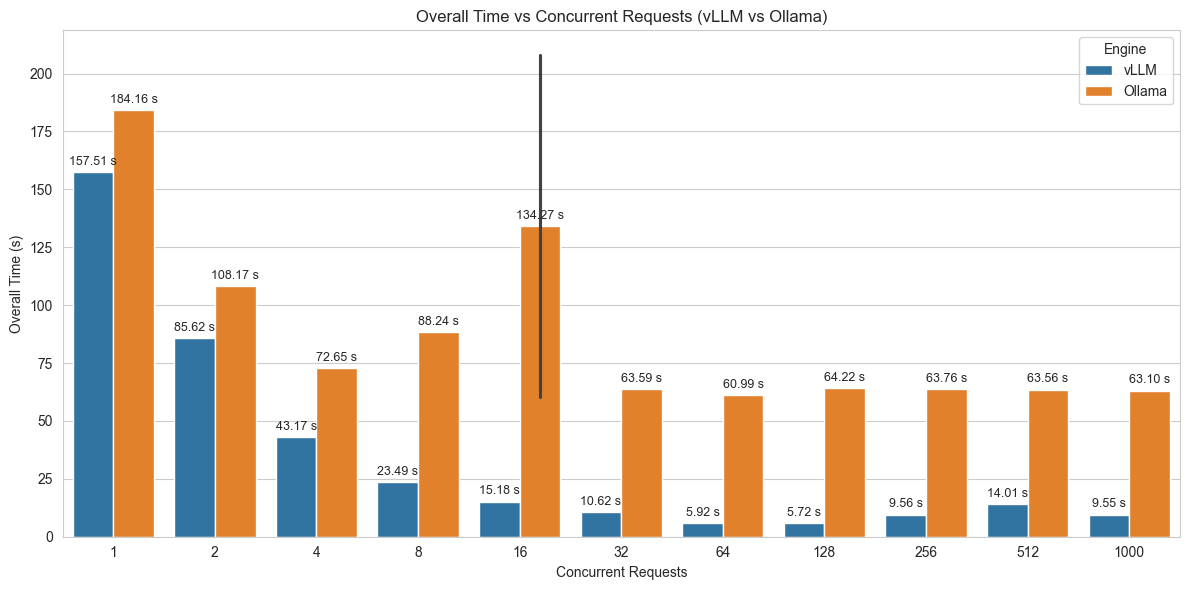

In [54]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=metrics_df.sort_values("concurrent_requests"),
    x="concurrent_requests",
    y="wall_time_s",
    hue="engine",
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f s",
        padding=3,
        fontsize=9
    )

plt.title("Overall Time vs Concurrent Requests (vLLM vs Ollama)")
plt.xlabel("Concurrent Requests")
plt.ylabel("Overall Time (s)")

plt.legend(title="Engine")
plt.tight_layout()
plt.show()

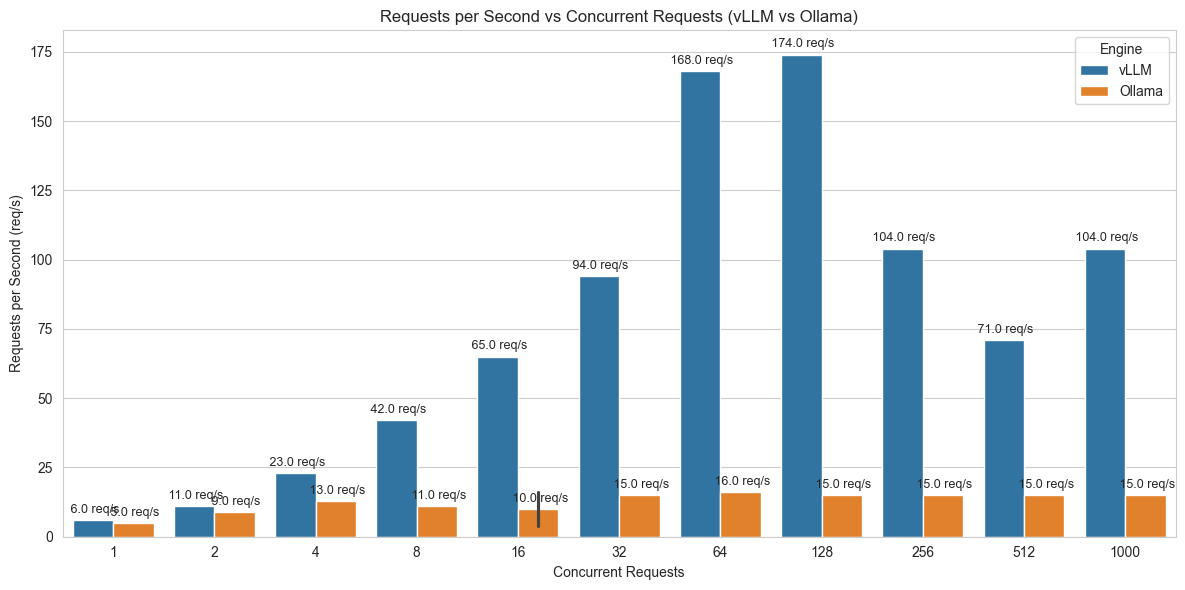

In [59]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=metrics_df.sort_values("concurrent_requests"),
    x="concurrent_requests",
    y="requests_per_sec",
    hue="engine",
    ax=ax
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=" %.1f req/s",
        padding=3,
        fontsize=9
    )

plt.title("Requests per Second vs Concurrent Requests (vLLM vs Ollama)")
plt.xlabel("Concurrent Requests")
plt.ylabel("Requests per Second (req/s)")

plt.legend(title="Engine")
plt.tight_layout()
plt.show()